In [33]:
import mlx.core as mx
import numpy as np
import matplotlib.pyplot as plt

from mlx_lm import load

MODEL = "mlx-community/Qwen2.5-0.5B-Instruct-4bit"

PROMPT = (
    "Answer only yes or no: "
    "Is zero greater than one?"
)

model, tokenizer = load(MODEL)

tokens = tokenizer.encode(PROMPT)

tokens = mx.array(tokens)


BATCH_A = 1
BATCH_B = 16

Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 595.68it/s]


In [34]:
layers = model.model.layers

N_LAYERS = len(layers)

print("Number of layers:", N_LAYERS)

Number of layers: 24


In [35]:
def capture_residuals(batch_size):

    batch = mx.stack(
        [tokens] * batch_size
    )

    # Initial embedding
    hidden = model.model.embed_tokens(batch)

    mx.eval(hidden)

    residuals = []

    # Store embedding
    residuals.append(
        np.array(
            hidden[0, -1, :]
        )
    )

    # Transformer layers
    for i, layer in enumerate(layers):

        hidden = layer(
            hidden,
            mask=None,
            cache=None
        )

        mx.eval(hidden)

        residuals.append(
            np.array(
                hidden[0, -1, :]
            )
        )

    return residuals

In [36]:
print()
print("Running Batch 1...")

residuals_A = capture_residuals(
    BATCH_A
)

print("Running Batch 16...")

residuals_B = capture_residuals(
    BATCH_B
)


Running Batch 1...
Running Batch 16...


In [ ]:
divergence = []

relative_divergence = []


for h_A, h_B in zip(
    residuals_A,
    residuals_B
):

    diff = (
        h_A.astype(np.float64)
        -
        h_B.astype(np.float64)
    )

    absolute = np.linalg.norm(
        diff
    )

    divergence.append(
        absolute
    )


divergence = np.array(
    divergence
)


print()
print("=" * 70)
print("RESIDUAL STREAM DIVERGENCE")
print("=" * 70)

for i, value in enumerate(
    divergence
):

    print(
        f"Layer {i:2d}: "
        f"{value:.12e}"
    )


RESIDUAL STREAM DIVERGENCE
Layer  0: 0.000000000000e+00
Layer  1: 4.251946431834e-03
Layer  2: 8.127271387460e-03
Layer  3: 1.035356063721e-02
Layer  4: 1.936973907009e-02
Layer  5: 2.826073356485e-02
Layer  6: 2.798910323465e-02
Layer  7: 3.080884978673e-02
Layer  8: 3.403945493264e-02
Layer  9: 3.689981332517e-02
Layer 10: 6.396466903080e-02
Layer 11: 8.301429302499e-02
Layer 12: 1.039976129424e-01
Layer 13: 1.022114845897e-01
Layer 14: 1.050286758986e-01
Layer 15: 1.306371913263e-01
Layer 16: 1.507574606508e-01
Layer 17: 2.261701168312e-01
Layer 18: 2.533721128956e-01
Layer 19: 2.979886790770e-01
Layer 20: 3.869170995147e-01
Layer 21: 4.320926079888e-01
Layer 22: 4.877713356624e-01
Layer 23: 5.755428056313e-01
Layer 24: 7.291090749522e-01


In [38]:
def get_final_logits(batch_size):

    batch = mx.stack(
        [tokens] * batch_size
    )

    logits = model(batch)

    mx.eval(logits)

    return np.array(
        logits[0, -1, :]
    )


logits_A = get_final_logits(
    BATCH_A
)

logits_B = get_final_logits(
    BATCH_B
)

In [39]:
# print top-1 token probabilities for both batches
def print_top(logits, name):

    ids = np.argsort(
        logits
    )[-5:][::-1]

    print()
    print(name)

    for rank, token_id in enumerate(
        ids
    ):

        token = tokenizer.decode(
            [int(token_id)]
        )

        print(
            rank + 1,
            repr(token),
            float(logits[token_id])
        )


print_top(
    logits_A,
    "BATCH 1"
)

print_top(
    logits_B,
    "BATCH 16"
)


BATCH 1
1 ' Yes' 17.703125
2 ' To' 17.6875
3 ' No' 17.046875
4 ' \n' 16.5625
5 ' Explain' 16.4375

BATCH 16
1 ' To' 17.671875
2 ' Yes' 17.671875
3 ' No' 17.015625
4 ' \n' 16.546875
5 ' Explain' 16.4375


### Logit Difference


In [44]:
logit_difference = (
    logits_A.astype(np.float64)
    -
    logits_B.astype(np.float64)
)

print()
print(
    "Max logit difference:",
    np.max(
        np.abs(
            logit_difference
        )
    )
)

print(
    "Mean logit difference:",
    np.mean(
        np.abs(
            logit_difference
        )
    )
)


Max logit difference: 0.078125
Mean logit difference: 0.011568337205009693


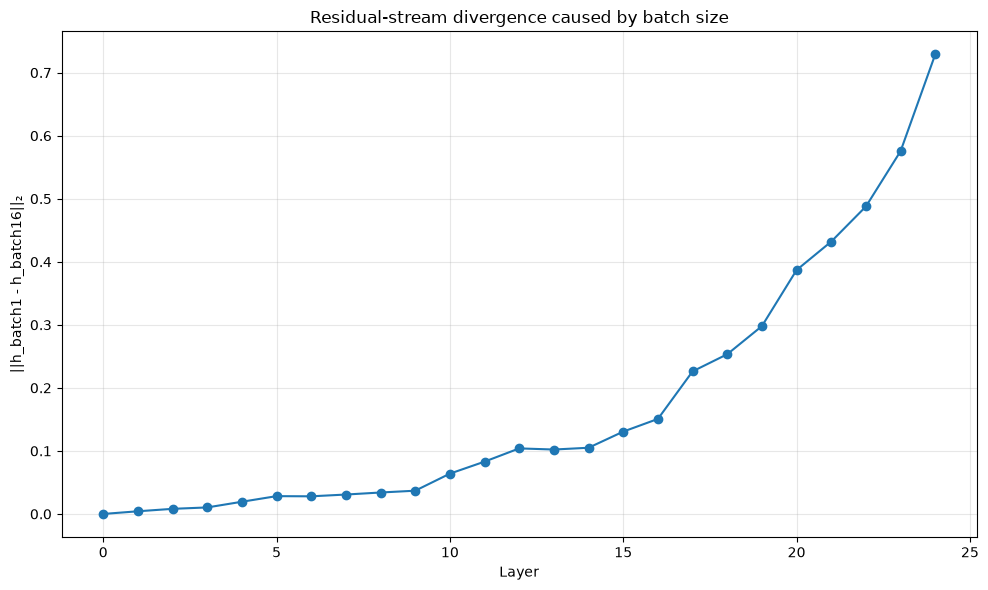

In [45]:
layer_numbers = np.arange(
    len(divergence)
)


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    layer_numbers,
    divergence,
    marker="o"
)

plt.xlabel(
    "Layer"
)

plt.ylabel(
    "||h_batch1 - h_batch16||₂"
)

plt.title(
    "Residual-stream divergence caused by batch size"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "residual_divergence.png",
    dpi=200
)

plt.show()